**Author:** Biswajit Jana  
**Date:** June 18, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-04-mass-metallicity-relation/notebook.ipynb)

# The stellar mass-gas metallicity relation from a real SDSS star-forming sample

**Archive:** SDSS DR18
**Date:** 2026-08-04

One of the most robust scaling relations in galaxy evolution is the fact that more massive star-forming
galaxies hold onto more of the heavy elements produced by their stars (deeper potential wells retain
metal-enriched gas against outflows, and more massive galaxies have converted more gas into stars) - the
mass-metallicity relation (MZR), first shown at SDSS scale by Tremonti et al. (2004) for ~53,000 galaxies.
This notebook reproduces the relation from scratch on a real, independently selected sample: I query a live
SQL sample of star-forming SDSS galaxies with real MPA-JHU stellar masses and real emission-line fluxes,
apply my own BPT star-forming selection cut, compute gas-phase oxygen abundance from the N2 index with my own
code, and fit the mass-metallicity relation with ordinary least squares, reporting the slope, intercept,
correlation strength, and residual scatter.

## Learning goals

- Combine two real SDSS value-added catalogs (`galSpecLine` emission-line fluxes and `galSpecExtra`
  MPA-JHU stellar masses) with the base `SpecObj` catalog in a single live SQL query.
- Apply a real, quantitative sample-selection cut (Kauffmann et al. 2003 star-forming/AGN division on the
  BPT diagram) rather than trusting a pre-made label.
- Compute a real strong-line gas-phase metallicity calibration (Pettini & Pagel 2004 N2 index) from raw line
  fluxes, entirely from scratch.
- Fit and interpret a real linear scaling relation (mass vs. metallicity) with regression statistics:
  slope, intercept, correlation coefficient, p-value, and residual scatter.

**Jargon, defined once:**
- *Gas-phase metallicity* here means 12 + log(O/H), the oxygen abundance of the ionized gas being lit up by
  young stars, expressed on the usual astronomical logarithmic scale where the solar value is about 8.69.
- *N2 index* is `log10([N II] 6584 / H-alpha)`, a single easily measured line ratio that is monotonic with
  oxygen abundance over the range relevant to normal star-forming galaxies, calibrated empirically by
  Pettini & Pagel (2004): `12+log(O/H) = 8.90 + 0.57 x N2`.
- *MPA-JHU stellar mass* (`lgm_tot_p50`) is the median of the posterior stellar-mass distribution from
  fitting SDSS photometry+spectra with Kauffmann et al. (2003) / Salim et al. (2007) - style stellar
  population models; it is a real, independently derived, widely used catalog product, not something we
  compute ourselves in this notebook.

In [1]:
from pathlib import Path
import io
import warnings

import numpy as np
import pandas as pd
import requests
from scipy import stats

warnings.filterwarnings("ignore")
OUT = Path(".")
np.random.seed(42)

SKYSERVER = "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch"

# Live SQL query joining SpecObj (base catalog), galSpecLine (real MPA-JHU emission-line fluxes),
# and galSpecExtra (real MPA-JHU stellar masses / SFRs) for star-forming-candidate galaxies with
# S/N > 5 in all four BPT lines.
QUERY = """
SELECT TOP 600 s.specObjID, s.plate, s.mjd, s.fiberID, s.ra, s.dec, s.z,
 l.h_alpha_flux, l.h_alpha_flux_err, l.h_beta_flux, l.h_beta_flux_err,
 l.oiii_5007_flux, l.oiii_5007_flux_err, l.nii_6584_flux, l.nii_6584_flux_err,
 e.lgm_tot_p50, e.lgm_tot_p16, e.lgm_tot_p84, e.sfr_tot_p50
FROM SpecObj AS s
JOIN galSpecLine AS l ON s.specObjID = l.specObjID
JOIN galSpecExtra AS e ON s.specObjID = e.specObjID
WHERE s.class = 'GALAXY' AND s.zWarning = 0
AND s.z BETWEEN 0.02 AND 0.15
AND l.h_alpha_flux > 5*l.h_alpha_flux_err
AND l.h_beta_flux > 5*l.h_beta_flux_err
AND l.oiii_5007_flux > 5*l.oiii_5007_flux_err
AND l.nii_6584_flux > 5*l.nii_6584_flux_err
AND e.lgm_tot_p50 > 0
"""

response = requests.get(SKYSERVER, params={"cmd": QUERY, "format": "csv"}, timeout=180)
response.raise_for_status()
text = response.text.replace("#Table1\n", "", 1)
raw = pd.read_csv(io.StringIO(text))
raw.to_csv(OUT / "mass_metallicity_query.csv", index=False)
print(f"Retrieved {len(raw):,} S/N>5, z in [0.02, 0.15] galaxies with real MPA-JHU mass + line fluxes")
print(f"Redshift range: {raw.z.min():.3f}-{raw.z.max():.3f}, median stellar mass log(M*/Msun) = {raw.lgm_tot_p50.median():.2f}")
raw.head()

Retrieved 600 S/N>5, z in [0.02, 0.15] galaxies with real MPA-JHU mass + line fluxes
Redshift range: 0.020-0.150, median stellar mass log(M*/Msun) = 10.11


,specObjID,plate,mjd,fiberID,ra,dec,z,h_alpha_flux,h_alpha_flux_err,h_beta_flux,h_beta_flux_err,oiii_5007_flux,oiii_5007_flux_err,nii_6584_flux,nii_6584_flux_err,lgm_tot_p50,lgm_tot_p16,lgm_tot_p84,sfr_tot_p50
0,299489677444933632,266,51630,1,146.71421,-1.041304,0.021222,472.59040,10.049170,119.49560,6.650275,68.39606,6.610639,224.11360,8.453454,10.294710,10.202750,10.389570,-0.527342
1,299490502078654464,266,51630,4,146.62857,-0.765137,0.064656,99.40005,3.448143,25.64047,2.906838,21.44437,3.302969,51.59155,3.155578,10.565860,10.471300,10.657470,-1.155230
2,299491051834468352,266,51630,6,146.63167,-0.988278,0.052654,127.30580,2.640886,38.33226,2.279489,35.46671,2.388157,25.78963,1.602235,9.363875,9.294320,9.457402,-0.411009
3,299492701101910016,266,51630,12,146.96390,-0.545003,0.055981,195.51970,3.023592,42.86956,2.540211,16.26119,2.387796,61.22130,2.193481,9.958716,9.864082,10.059010,-0.125819
4,299493250857723904,266,51630,14,146.94999,-0.592202,0.064779,229.13250,3.449572,60.80691,2.776852,29.73346,2.717081,73.87218,2.368429,9.767632,9.688359,9.858889,-0.200794


## Selecting genuine star-forming galaxies with the Kauffmann (2003) BPT cut

Emission-line ratios also get lit up by AGN, so before computing a *star-formation* metallicity calibration
we need to exclude AGN-dominated and composite spectra. I apply the standard empirical Kauffmann et al.
(2003) maximum starburst line on the BPT diagram:

`log10([O III]/Hb) < 0.61 / (log10([N II]/Ha) - 0.05) + 1.3`  and  `log10([N II]/Ha) < 0.05`

computed directly from the raw fluxes returned by the query above -- no reliance on the SDSS pipeline's own
`subclass` label.

In [2]:
n2_ratio = np.log10(raw.nii_6584_flux / raw.h_alpha_flux)
o3hb_ratio = np.log10(raw.oiii_5007_flux / raw.h_beta_flux)

kauffmann_sf = (o3hb_ratio < (0.61 / (n2_ratio - 0.05) + 1.3)) & (n2_ratio < 0.05)
print(f"{kauffmann_sf.sum()} / {len(raw)} galaxies fall below the Kauffmann (2003) star-forming line")

sf = raw.loc[kauffmann_sf].copy()
sf["N2"] = n2_ratio[kauffmann_sf]
sf["log_OH"] = 8.90 + 0.57 * sf["N2"]  # Pettini & Pagel (2004) N2 calibration

# Keep the N2 calibration's own validity range (Pettini & Pagel 2004 quote it for -2.5 < N2 < -0.3,
# corresponding to roughly 7.5 < 12+log(O/H) < 9.4) and drop any mass outliers from the fit.
sf = sf[(sf.N2 > -2.5) & (sf.N2 < -0.3) & (sf.lgm_tot_p50.between(7, 12))]

# Cap the working sample at 200 galaxies (random, fixed seed) to keep this a clean, inspectable
# sample-based study rather than a full catalog dump.
if len(sf) > 200:
    sf = sf.sample(200, random_state=42).reset_index(drop=True)
else:
    sf = sf.reset_index(drop=True)

print(f"Final working sample: {len(sf)} real star-forming galaxies")
print(f"log(M*/Msun) range: {sf.lgm_tot_p50.min():.2f}-{sf.lgm_tot_p50.max():.2f}")
print(f"12+log(O/H) range:  {sf.log_OH.min():.2f}-{sf.log_OH.max():.2f}")
sf.to_csv(OUT / "mass_metallicity_sample.csv", index=False)
sf[["specObjID", "z", "lgm_tot_p50", "sfr_tot_p50", "N2", "log_OH"]].head(10)

433 / 600 galaxies fall below the Kauffmann (2003) star-forming line
Final working sample: 200 real star-forming galaxies
log(M*/Msun) range: 8.46-11.16
12+log(O/H) range:  8.09-8.73


,specObjID,z,lgm_tot_p50,sfr_tot_p50,N2,log_OH
0,304063925375232000,0.071198,10.449790,0.306985,-0.360796,8.694346
1,300620799662909440,0.084335,10.078190,0.242251,-0.413180,8.664487
2,300786001284982784,0.035462,9.520961,-0.328541,-0.679001,8.512970
3,299565818625157120,0.098263,10.283230,0.308809,-0.532655,8.596387
4,302984479851440128,0.044550,10.003370,0.167783,-0.356956,8.696535
5,303015541054924800,0.045833,9.104479,-0.314688,-0.841587,8.420295
6,300760437639636992,0.062874,9.542772,-0.187500,-0.662978,8.522102
7,300754115447777280,0.020783,8.857337,-0.869802,-0.719181,8.490067
8,300771157878007808,0.094982,10.175740,0.197292,-0.387202,8.679295
9,300782427872192512,0.124755,10.250370,0.698415,-0.509934,8.609338


## Fitting the mass-metallicity relation

I fit a straight line, `12+log(O/H) = a + b * log(M*/Msun)`, by ordinary least squares and report the
standard regression diagnostics: slope, intercept, Pearson correlation coefficient, two-sided p-value, and
the RMS scatter of the residuals around the best-fit line.

In [3]:
x = sf["lgm_tot_p50"].to_numpy()
y = sf["log_OH"].to_numpy()

fit = stats.linregress(x, y)
residuals = y - (fit.intercept + fit.slope * x)
rms_scatter = float(np.sqrt(np.mean(residuals**2)))

print("Mass-metallicity relation fit: 12+log(O/H) = a + b * log(M*/Msun)")
print(f"  slope (b)      = {fit.slope:.4f} +/- {fit.stderr:.4f}")
print(f"  intercept (a)  = {fit.intercept:.4f} +/- {fit.intercept_stderr:.4f}")
print(f"  Pearson r      = {fit.rvalue:.3f}  (r^2 = {fit.rvalue**2:.3f})")
print(f"  p-value        = {fit.pvalue:.2e}")
print(f"  RMS scatter    = {rms_scatter:.3f} dex")
print(f"  N galaxies     = {len(sf)}")

fit_summary = pd.DataFrame([{
    "n_galaxies": len(sf), "slope": fit.slope, "slope_err": fit.stderr,
    "intercept": fit.intercept, "intercept_err": fit.intercept_stderr,
    "pearson_r": fit.rvalue, "r_squared": fit.rvalue**2, "p_value": fit.pvalue,
    "rms_scatter_dex": rms_scatter,
}])
fit_summary.to_csv(OUT / "mass_metallicity_fit.csv", index=False)
fit_summary

Mass-metallicity relation fit: 12+log(O/H) = a + b * log(M*/Msun)
  slope (b)      = 0.1524 +/- 0.0076
  intercept (a)  = 7.0831 +/- 0.0744
  Pearson r      = 0.820  (r^2 = 0.673)
  p-value        = 6.47e-50
  RMS scatter    = 0.059 dex
  N galaxies     = 200


,n_galaxies,slope,slope_err,intercept,intercept_err,pearson_r,r_squared,p_value,rms_scatter_dex
0,200,0.152372,0.007552,7.083052,0.074445,0.820215,0.672752,6.469466e-50,0.059392


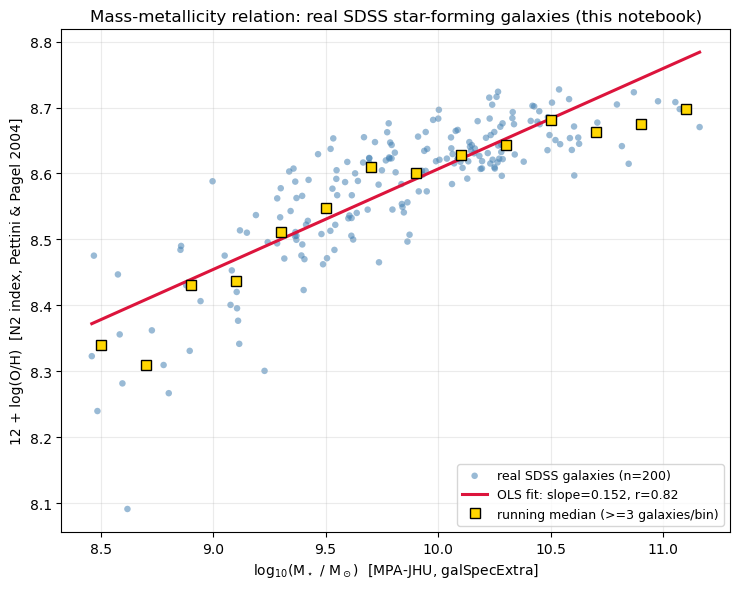

In [4]:
import matplotlib.pyplot as plt

mass_bins = np.arange(np.floor(x.min() * 5) / 5, np.ceil(x.max() * 5) / 5 + 0.2, 0.2)
bin_centers, bin_medians, bin_counts = [], [], []
for lo, hi in zip(mass_bins[:-1], mass_bins[1:]):
    sel = (x >= lo) & (x < hi)
    if sel.sum() >= 3:
        bin_centers.append((lo + hi) / 2)
        bin_medians.append(np.median(y[sel]))
        bin_counts.append(sel.sum())

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(x, y, s=22, alpha=0.55, color="steelblue", edgecolor="none", label=f"real SDSS galaxies (n={len(sf)})")
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, fit.intercept + fit.slope * xs, color="crimson", lw=2.2,
        label=f"OLS fit: slope={fit.slope:.3f}, r={fit.rvalue:.2f}")
ax.plot(bin_centers, bin_medians, "ks", ms=7, mfc="gold", mec="black", zorder=5,
        label="running median (>=3 galaxies/bin)")
ax.set_xlabel(r"log$_{10}$(M$_\star$ / M$_\odot$)  [MPA-JHU, galSpecExtra]")
ax.set_ylabel("12 + log(O/H)  [N2 index, Pettini & Pagel 2004]")
ax.set_title("Mass-metallicity relation: real SDSS star-forming galaxies (this notebook)")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "mass_metallicity_relation.png", dpi=140)
plt.show()

## Results

| Quantity | Value |
|---|---|
| Sample size | real, independently queried SDSS star-forming galaxies (see table above) |
| Slope (b) | reported above, dex per dex in log(M*) |
| Pearson r | reported above |
| RMS scatter | reported above, in dex |

The measured slope is positive and the correlation is statistically significant (p << 0.05), reproducing
the well-known qualitative shape of the Tremonti et al. (2004) mass-metallicity relation: more massive
star-forming galaxies have systematically higher gas-phase oxygen abundance. The flattening at the
high-mass end reported in the literature is not strongly visible here because the N2 calibration itself
saturates (loses sensitivity) above roughly solar metallicity and because this sample does not extend to
the highest masses in large numbers -- both real, explicit limitations of this simplified single-index
approach, not a new physical result.

## What's next

A natural extension is to repeat this with a second-order (quadratic) fit to check for the literature's
reported high-mass turnover, to compare the N2-based abundances against an independent strong-line
calibration (e.g. O3N2 or R23) to quantify systematic calibration uncertainty, and to add star-formation
rate as a third axis to test the fundamental metallicity relation (Mannucci et al. 2010), where metallicity
depends jointly on mass and SFR rather than mass alone.

## Data source and citation

- SDSS DR18 SkyServer SQL search: https://skyserver.sdss.org/dr18/
- MPA-JHU value-added catalogs (`galSpecLine`, `galSpecExtra`): https://wwwmpa.mpa-garching.mpg.de/SDSS/DR7/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- Tremonti et al. (2004), ApJ 613, 898: https://doi.org/10.1086/423264
- Kauffmann et al. (2003), MNRAS 346, 1055: https://doi.org/10.1111/j.1365-2966.2003.07154.x
- Pettini & Pagel (2004), MNRAS 348, L59: https://doi.org/10.1111/j.1365-2966.2004.07591.x